# CC3182 – Visión por Computadora
## Laboratorio 10 – Task 2: Escenario B (Modelo Destilado)

Modelo destilado utilizado: SimianLuo/LCM_Dreamshaper_v7
Es un modelo LCM (Latent Consistency Distillation). Válido como representante del paradigma de destilación para inferencia ultra rápida

In [ ]:
!pip install diffusers transformers accelerate torch torchvision --quiet

In [2]:
import time
import torch
import matplotlib.pyplot as plt
from diffusers import DiffusionPipeline, LCMScheduler
from huggingface_hub import login
from PIL import Image
import os

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Dispositivo: cuda
GPU: Tesla T4
VRAM total: 14.56 GB


## 1. Carga modelo LCM

In [4]:
from huggingface_hub import login

HF_TOKEN = "repo publico, no subo token"
login(token=HF_TOKEN, add_to_git_credential=False)

pipe_lcm = DiffusionPipeline.from_pretrained(
    "SimianLuo/LCM_Dreamshaper_v7",
    torch_dtype=torch.float16,
    token=HF_TOKEN
)

# LCM requiere su propio scheduler
pipe_lcm.scheduler = LCMScheduler.from_config(pipe_lcm.scheduler.config)
pipe_lcm = pipe_lcm.to(device)

print("Modelo LCM_Dreamshaper_v7 cargado correctamente.")
print(f"Scheduler activo: {pipe_lcm.scheduler.__class__.__name__}")

model_index.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Modelo LCM_Dreamshaper_v7 cargado correctamente.
Scheduler activo: LCMScheduler


# 2. Generacion con 4 pasos

In [5]:
# Mismo prompt y seed que Escenario A
PROMPT         = "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution"
SEED           = 42
NUM_STEPS_B    = 4
GUIDANCE_SCALE = 1.0   # LCM: entre 1.0–2.0 (no 0.0 como SD-Turbo)

# Resetear estadísticas de VRAM
if device == "cuda":
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

# --- Inicio de medición ---
t_start   = time.time()
generator = torch.Generator(device=device).manual_seed(SEED)

result_b = pipe_lcm(
    prompt=PROMPT,
    num_inference_steps=NUM_STEPS_B,
    guidance_scale=GUIDANCE_SCALE,
    generator=generator,
    width=512,
    height=512
)

if device == "cuda":
    torch.cuda.synchronize()
t_end = time.time()
# --- Fin de medición ---

time_b  = t_end - t_start
vram_b  = torch.cuda.max_memory_allocated() / 1024**2 if device == "cuda" else 0  # MB
image_b = result_b.images[0]

print(f"Escenario B – LCM_Dreamshaper_v7 (destilado)")
print(f"  Pasos de inferencia : {NUM_STEPS_B}")
print(f"  Tiempo de ejecución : {time_b:.2f} segundos")
print(f"  VRAM máxima usada   : {vram_b:.1f} MB  ({vram_b/1024:.2f} GB)")

  0%|          | 0/4 [00:00<?, ?it/s]

Escenario B – LCM_Dreamshaper_v7 (destilado)
  Pasos de inferencia : 4
  Tiempo de ejecución : 2.82 segundos
  VRAM máxima usada   : 3257.3 MB  (3.18 GB)


In [6]:
image_b.save("escenario_b_lcm.png")
print("Imagen guardada: escenario_b_lcm.png")

Imagen guardada: escenario_b_lcm.png


# 3. Imagen

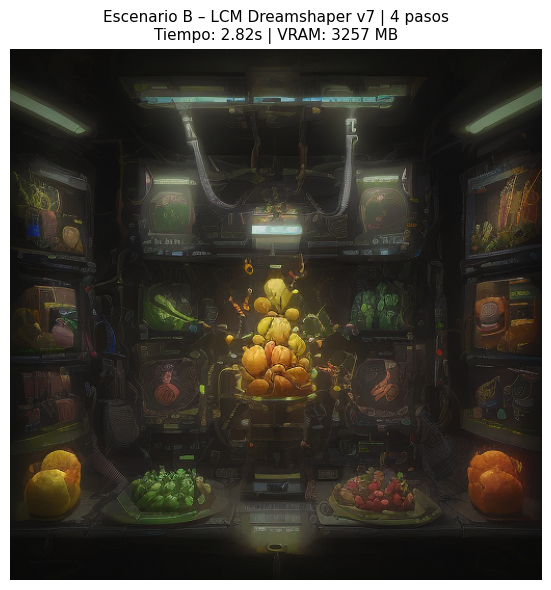

Figura guardada: escenario_b_resultado.png


In [7]:
plt.figure(figsize=(6, 6))
plt.imshow(image_b)
plt.axis("off")
plt.title(
    f"Escenario B – LCM Dreamshaper v7 | {NUM_STEPS_B} pasos\n"
    f"Tiempo: {time_b:.2f}s | VRAM: {vram_b:.0f} MB",
    fontsize=11
)
plt.tight_layout()
plt.savefig("escenario_b_resultado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: escenario_b_resultado.png")

# Rendimiento + Comparativa

In [8]:
# ── valores reales del Escenario A ──
time_a = 10.39
vram_a = 3.18

sep = "=" * 65
div = "-" * 65
print(f"\n{sep}")
print(f"{'TABLA COMPARATIVA – TASK 2':^65}")
print(f"{sep}")
print(f"{'Métrica':<30} {'Escenario A':>16} {'Escenario B':>16}")
print(div)
print(f"{'Modelo':<30} {'SD 1.5 (base)':>16} {'LCM Dreamshaper v7':>16}")
print(f"{'Tipo':<30} {'Estándar':>16} {'Destilado (LCD)':>16}")
print(f"{'Pasos de inferencia':<30} {50:>16} {NUM_STEPS_B:>16}")
print(f"{'Tiempo (s)':<30} {time_a:>15.2f}s {time_b:>15.2f}s")
print(f"{'VRAM máx (MB)':<30} {vram_a:>15.1f}  {vram_b:>15.1f} ")
print(f"{'VRAM máx (GB)':<30} {vram_a/1024:>15.2f}  {vram_b/1024:>15.2f} ")
print(f"{sep}")


                   TABLA COMPARATIVA – TASK 2                    
Métrica                             Escenario A      Escenario B
-----------------------------------------------------------------
Modelo                            SD 1.5 (base) LCM Dreamshaper v7
Tipo                                   Estándar  Destilado (LCD)
Pasos de inferencia                          50                4
Tiempo (s)                               10.39s            2.82s
VRAM máx (MB)                              3.2           3257.3 
VRAM máx (GB)                             0.00             3.18 
